# NBA 3-Point Percentage Prediction (2025–26)

**Author:** Allen Solomon  
**Date:** April 16, 2026  

---

## Objective

The goal of this project is to predict NBA players’ three-point percentage (3P%) for the 2025–26 season using historical player data.

Rather than relying only on past 3P%, this project incorporates:

- Shooting volume (3PA)
- Shot selection tendencies
- Zone-based shooting efficiency

This allows for a more complete understanding of player shooting ability and behavior.

## Data Collection

Data was collected using the NBA Stats API via the `nba_api` Python package.

Two main datasets were built:

1. **Core Player Stats**
   - Age
   - 3PA
   - 3P%
   - Total shooting stats

2. **Shot Profile Data**
   - Left corner 3%
   - Right corner 3%
   - Above-the-break 3%
   - Shot distribution tendencies

Seasons included:

**2014–15 through 2024–25**

No data from the 2025–26 season was used to avoid data leakage.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

modeling_df = pd.read_csv("../data/processed/modeling_dataset.csv")
modeling_df.head()

,PLAYER_ID,NAME,AGE,TEAM,FGA,3PA,3P_PCT,SEASON,SHOT_FREQUENCY_PCT,TEAM_ID,...,LEFT_CORNER_3_PCT,RIGHT_CORNER_3_FGM,RIGHT_CORNER_3_FGA,RIGHT_CORNER_3_PCT,ABOVE_THE_BREAK_3_FGM,ABOVE_THE_BREAK_3_FGA,ABOVE_BREAK_3_PCT,CORNER_3_FGM,CORNER_3_FGA,CORNER_3_PCT
0,201985,AJ Price,28.0,CLE,137,57,0.263,2014-15,0.416058,1610612739,...,0.200,0.0,2.0,0.000,14.0,50.0,0.280,1.0,7.0,0.143
1,201166,Aaron Brooks,30.0,CHI,817,313,0.387,2014-15,0.383109,1610612741,...,0.190,9.0,17.0,0.529,108.0,273.0,0.396,13.0,38.0,0.342
2,203932,Aaron Gordon,19.0,ORL,208,48,0.271,2014-15,0.230769,1610612753,...,0.200,7.0,16.0,0.438,4.0,21.0,0.190,9.0,26.0,0.346
3,203940,Adreian Payne,24.0,MIN,220,9,0.111,2014-15,0.040909,1610612750,...,0.000,0.0,1.0,0.000,1.0,8.0,0.125,0.0,1.0,0.000
4,201143,Al Horford,29.0,ATL,965,36,0.306,2014-15,0.037306,1610612737,...,0.273,8.0,18.0,0.444,0.0,7.0,0.000,11.0,29.0,0.379


In [14]:
import sys
print(sys.executable)

c:\Users\allen\anaconda3\envs\nba_env\python.exe


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn nba_api

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------------------ --------------- 7.1/11.3 MB 39.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 35.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------- ----------------------------- 3.4/12.9 MB 18.4 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/12.9 MB 23.1 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 23.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Imports work")

Imports work


## Data Processing Pipeline

The dataset was built using a multi-step pipeline:

1. Extract player season statistics
2. Collect shot location data using the NBA API
3. Aggregate shooting percentages by zone
4. Merge datasets using PLAYER_ID and SEASON
5. Create next-season target variable

This structured pipeline ensures reproducibility and consistency.

## Distribution of 3-Point Percentage

This plot shows the distribution of player 3-point percentages in the dataset.

Most players cluster between 30% and 40%, with fewer elite shooters above 40%.

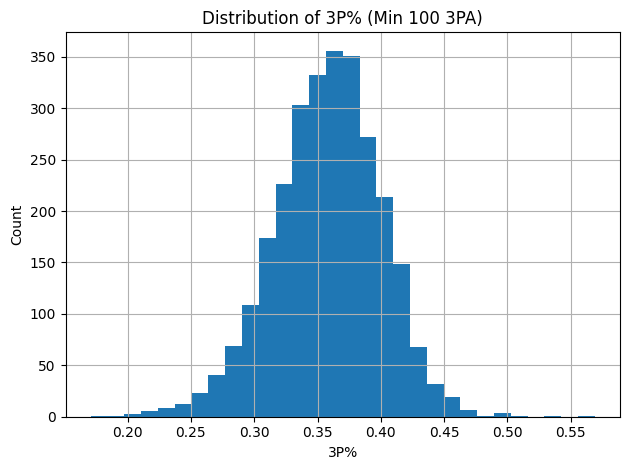

In [29]:
filtered_df = modeling_df[modeling_df["3PA"] >= 100]

plt.figure()
filtered_df["3P_PCT"].hist(bins=30)

plt.title("Distribution of 3P% (Min 100 3PA)")
plt.xlabel("3P%")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Feature Engineering

The following features were used:

- AGE
- 3PA (3-point attempts)
- SHOT_FREQUENCY_PCT (3PA / FGA)
- 3P_PCT (baseline shooting ability)
- LEFT_CORNER_3_PCT
- RIGHT_CORNER_3_PCT
- ABOVE_BREAK_3_PCT
- CORNER_3_PCT

These features capture both efficiency and shot selection tendencies.

In [16]:
print("Shape:", modeling_df.shape)
print("\nColumns:")
print(modeling_df.columns.tolist())

Shape: (5846, 22)

Columns:
['PLAYER_ID', 'NAME', 'AGE', 'TEAM', 'FGA', '3PA', '3P_PCT', 'SEASON', 'SHOT_FREQUENCY_PCT', 'TEAM_ID', 'LEFT_CORNER_3_FGM', 'LEFT_CORNER_3_FGA', 'LEFT_CORNER_3_PCT', 'RIGHT_CORNER_3_FGM', 'RIGHT_CORNER_3_FGA', 'RIGHT_CORNER_3_PCT', 'ABOVE_THE_BREAK_3_FGM', 'ABOVE_THE_BREAK_3_FGA', 'ABOVE_BREAK_3_PCT', 'CORNER_3_FGM', 'CORNER_3_FGA', 'CORNER_3_PCT']


## Target Variable

The target variable is the next season’s 3P%:

TARGET_3P_PCT = next season 3P_PCT

This was created using a groupby + shift operation.

In [10]:
train_df = pd.read_csv("../data/processed/training_table.csv")
train_df[["PLAYER_ID", "SEASON", "3P_PCT", "TARGET_3P_PCT"]].head(10)

,PLAYER_ID,SEASON,3P_PCT,TARGET_3P_PCT
0,708,2014-15,0.143,0.000
1,977,2014-15,0.293,0.285
2,1495,2014-15,0.286,0.000
3,1713,2014-15,0.297,0.349
4,1713,2015-16,0.349,0.378
5,1713,2016-17,0.378,0.345
6,1713,2017-18,0.345,0.389
7,1713,2018-19,0.389,0.302
8,1717,2014-15,0.380,0.368
9,1717,2015-16,0.368,0.378


## Model

A Ridge Regression model was used to predict future 3P%.

Why Ridge?

- Helps prevent overfitting
- Handles correlated features well
- Provides interpretable coefficients

Missing values were handled using:

- SimpleImputer (fill with 0)

A pipeline was used to ensure consistent preprocessing.

## Model Evaluation

Model performance was evaluated using RMSE (Root Mean Squared Error).

Final Model:

RMSE ≈ 0.1178

This means predictions are typically within ~11.8 percentage points of actual values.

## Predicted vs Actual Performance

This plot compares predicted 3P% to actual values from the test set.

A strong model should show points clustered around the diagonal line.

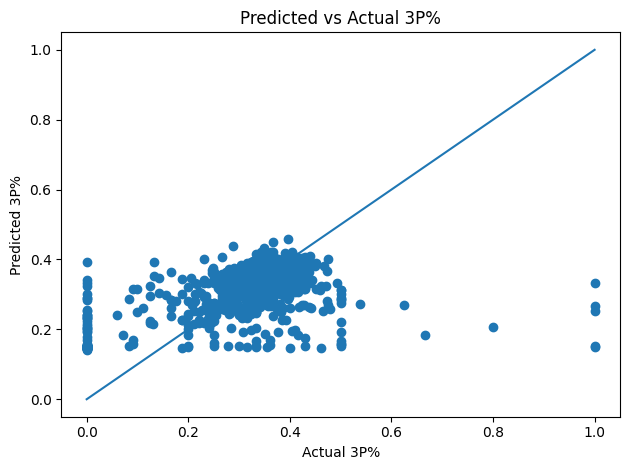

In [26]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

feature_cols = [
    "AGE", "3PA", "SHOT_FREQUENCY_PCT", "3P_PCT",
    "LEFT_CORNER_3_PCT", "RIGHT_CORNER_3_PCT",
    "ABOVE_BREAK_3_PCT", "CORNER_3_PCT"
]

target_col = "TARGET_3P_PCT"

df = pd.read_csv("../data/processed/training_table.csv")

for col in feature_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[target_col])

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

plt.figure()

plt.scatter(y_test, preds)

# perfect prediction line
plt.plot([0, 1], [0, 1])

plt.xlabel("Actual 3P%")
plt.ylabel("Predicted 3P%")
plt.title("Predicted vs Actual 3P%")

plt.tight_layout()
plt.show()

## Model Comparison

To evaluate the impact of feature engineering, a baseline model was compared to the final model.

Results:

- Baseline RMSE (using only 3P_PCT): 0.1206  
- Final RMSE (engineered features): 0.1178  
- Improvement: 0.0028  

This shows that incorporating shot profile data improves predictive performance.

## Feature Importance

Key predictors:

- SHOT_FREQUENCY_PCT (strongest signal)
- ABOVE_BREAK_3_PCT
- CORNER_3_PCT

This suggests that shot selection and shot type are strong indicators of future shooting performance.

The chart below shows the impact of each feature on the model’s predictions.

Positive values indicate a positive relationship with future 3P%.

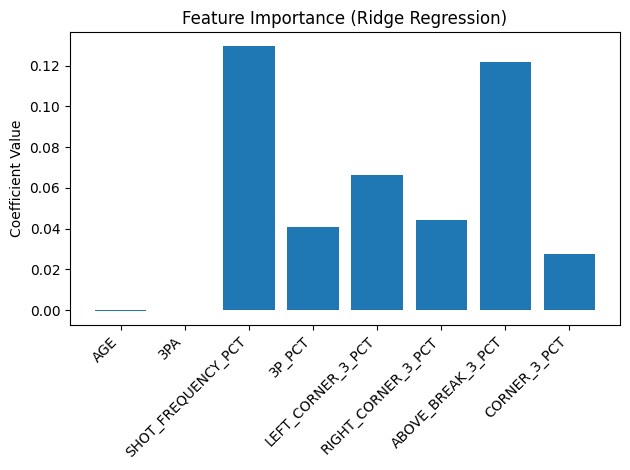

In [17]:
plt.figure()

plt.bar(feature_cols, coefs)

plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance (Ridge Regression)")
plt.ylabel("Coefficient Value")

plt.tight_layout()
plt.show()

The model coefficients indicate that shot frequency and above-the-break shooting percentage are among the strongest predictors of future 3-point performance. This suggests that both shot selection and shot type play a critical role in forecasting shooting efficiency.

## 2025–26 Predictions

Predictions were generated using 2024–25 data.

In [4]:
pred_df = pd.read_csv("../data/processed/predictions_2025_26.csv")
pred_df.head(10)

,PLAYER_ID,NAME,TEAM,AGE,3PA,3P_PCT,PREDICTED_3P_PCT_2025_26
0,1627736,Malik Beasley,DET,28.0,766,0.416,0.460
1,1630198,Isaiah Joe,OKC,25.0,466,0.412,0.442
2,1630202,Payton Pritchard,BOS,27.0,626,0.407,0.439
3,201939,Stephen Curry,GSW,37.0,784,0.397,0.438
4,1631260,AJ Green,MIL,25.0,363,0.427,0.437
5,1628401,Derrick White,BOS,30.0,691,0.384,0.434
6,1630162,Anthony Edwards,MIN,23.0,811,0.395,0.430
7,1630573,Sam Hauser,BOS,27.0,399,0.416,0.429
8,1626220,Royce O'Neale,PHX,32.0,441,0.406,0.425
9,1628369,Jayson Tatum,BOS,27.0,728,0.343,0.416


To improve reliability, players with fewer than 100 three-point attempts were excluded.

This removes small-sample noise and ensures predictions reflect meaningful shooting volume.

## Key Insights

- Players with higher 3PA volume tend to maintain performance
- Above-the-break shooting is highly predictive
- Shot selection matters as much as shooting skill
- Combining volume + efficiency improves predictions

## Data Engineering Challenges

Building the dataset required extensive interaction with the NBA API.

Challenges included:

- API rate limits and timeouts
- Failed requests
- Long runtime due to large data volume
- Missing values for some players/seasons

Solutions:

- Implemented retry logic
- Added delays between requests
- Saved checkpoint files during execution
- Handled missing values during modeling

This ensured robustness and reproducibility.

## Reproducibility

This project is fully reproducible using the provided scripts and notebook.

### 1. Install dependencies

```bash
pip install pandas numpy scikit-learn matplotlib nba_api
```

### 2. Run data pipeline (in order)

```bash
python build_core_dataset.py
python build_zone_dataset.py
python build_shot_profile_dataset.py
python merge_dataset.py
python create_training_table.py
python train_model.py
python predict_2025_26.py
```

### 3. Open the analysis notebook

```bash
notebooks/analysis.ipynb
```

### Notes

* Data is stored in `data/raw/` and `data/processed/`
* API calls may take time due to rate limiting
* Intermediate datasets are saved automatically during pipeline execution



## AI Assistance

AI tools (primarily Claude & ChatGPT) were used throughout this project to help with debugging, structuring code, and working through technical issues that came up along the way. Most of the assistance was focused on solving implementation challenges rather than making modeling decisions.

In particular, AI was helpful when working with the nba_api, which returns complex and sometimes inconsistent JSON structures. It was also useful for troubleshooting API timeouts and building retry logic when collecting large amounts of shot data.

Other areas where AI support was used include:

Creating the next-season target variable using groupby and shift
Handling missing values within a scikit-learn pipeline
Structuring the overall data pipeline (merging datasets and aligning seasons correctly)
Fixing environment and kernel issues in Jupyter Notebook
Generating and refining visualizations

Some example prompts used during development:

“Fix nested JSON structure from nba_api response”
“Create next-season target variable using pandas groupby and shift”
“Debug API timeout and retry logic”
“Explain how to visualize model coefficients in matplotlib”

All code generated with AI assistance was reviewed, tested, and adjusted as needed. The final modeling approach, feature selection, and analysis decisions were made independently.